In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
%matplotlib inline

# ── 1. CARREGANDO OS DADOS ──────────────────────────────────
df = pd.read_csv('ibov_retornos_simples.csv', index_col=0, parse_dates=True)
print(f"Shape total dos dados: {df.shape}")
print(f"Período total: {df.index.min().date()} a {df.index.max().date()}")

# ── 2. FILTRANDO OS ÚLTIMOS 7 ANOS ─────────────────────────
data_corte = df.index.max() - pd.DateOffset(years=7)
df_7anos = df[df.index >= data_corte].copy()
print(f"\nÚltimos 7 anos: {df_7anos.index.min().date()} a {df_7anos.index.max().date()}")
print(f"Shape filtrado:  {df_7anos.shape}")

Shape total dos dados: (1818, 62)
Período total: 2018-01-03 a 2025-04-30

Últimos 7 anos: 2018-04-30 a 2025-04-30
Shape filtrado:  (1738, 62)


In [2]:
# ── 3. CALCULANDO LIMITES DE OUTLIERS (MÉTODO IQR) ─────────
# Outlier superior: Q3 + 1.5 * IQR
# Outlier inferior: Q1 - 1.5 * IQR

Q1  = df_7anos.quantile(0.25)
Q3  = df_7anos.quantile(0.75)
IQR = Q3 - Q1

limite_sup = Q3 + 1.5 * IQR   # fence superior
limite_inf = Q1 - 1.5 * IQR   # fence inferior

# Contagem de outliers por ação
n_outliers_sup = (df_7anos > limite_sup).sum()
n_outliers_inf = (df_7anos < limite_inf).sum()
n_outliers_tot = n_outliers_sup + n_outliers_inf

resumo = pd.DataFrame({
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Fence_Inf': limite_inf,
        'Fence_Sup': limite_sup,
        'Outliers_Sup': n_outliers_sup,
        'Outliers_Inf': n_outliers_inf,
        'Total_Outliers': n_outliers_tot
})

print("=== RESUMO DOS LIMITES DE OUTLIERS ===")
print(resumo[['Fence_Inf','Fence_Sup','Total_Outliers']].to_string())

=== RESUMO DOS LIMITES DE OUTLIERS ===
           Fence_Inf  Fence_Sup  Total_Outliers
ABEV3.SA   -0.035718   0.035660              96
AXIA3.SA   -0.057235   0.058096              87
AXIA6.SA   -0.049134   0.051475              92
AZZA3.SA   -0.057746   0.057662              59
B3SA3.SA   -0.056233   0.057144              54
BBAS3.SA   -0.042377   0.043910              88
BBDC3.SA   -0.043958   0.043803              70
BBDC4.SA   -0.044989   0.045265              70
BBSE3.SA   -0.034084   0.035212              65
BEEF3.SA   -0.060702   0.060912              71
BPAC11.SA  -0.057006   0.060084              60
BRAP4.SA   -0.047321   0.048394              72
BRKM5.SA   -0.063168   0.060291              86
CMIG4.SA   -0.045379   0.047882              71
COGN3.SA   -0.079438   0.077308              60
CPFE3.SA   -0.034643   0.036089              71
CPLE3.SA   -0.042076   0.044401              62
CSAN3.SA   -0.057080   0.057136              48
CSMG3.SA   -0.043184   0.044679              86
C

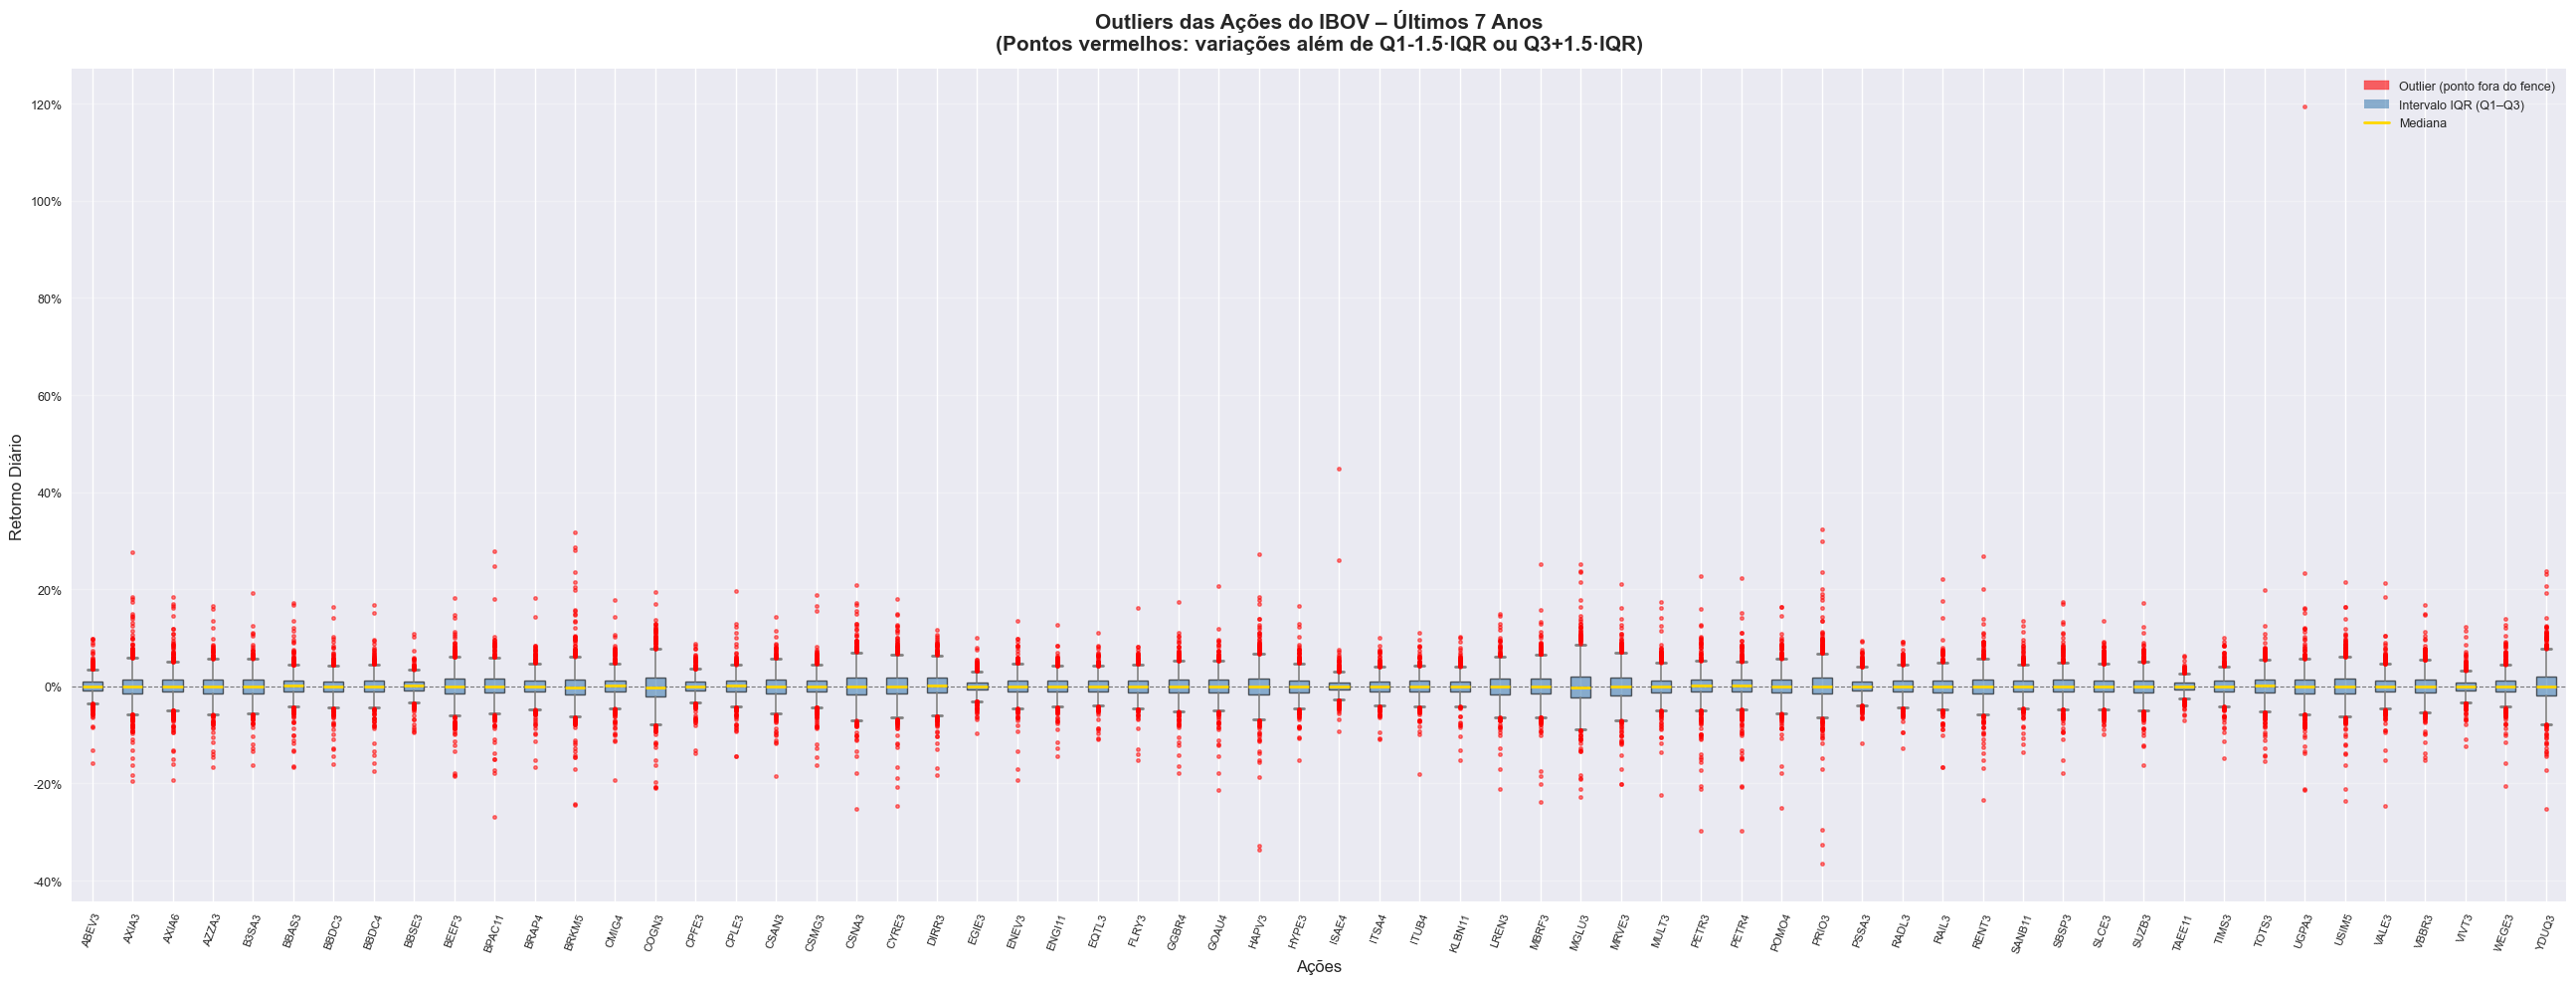

Gráfico salvo como 'outliers_boxplot_ibov.png'


In [3]:
# ── 4. BOXPLOT GERAL – TODOS AS AÇÕES (OUTLIERS EM DESTAQUE) ─
# O boxplot do matplotlib já usa a regra 1.5*IQR nativamente
# Os pontos plotados além dos "whiskers" SÃO os outliers

acoes = df_7anos.columns.tolist()
n_acoes = len(acoes)

fig, ax = plt.subplots(figsize=(26, 10))

bp = ax.boxplot(
        [df_7anos[col].dropna().values for col in acoes],
        labels=[c.replace('.SA', '') for c in acoes],
        patch_artist=True,
        showfliers=True,
        flierprops=dict(marker='o', markersize=2.5,
                                            markerfacecolor='red', markeredgecolor='red', alpha=0.5),
        medianprops=dict(color='gold', linewidth=2),
        boxprops=dict(facecolor='steelblue', alpha=0.6),
        whiskerprops=dict(color='gray', linewidth=1.2),
        capprops=dict(color='gray', linewidth=2),
)

# Linhas de referência
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

ax.set_title('Outliers das Ações do IBOV – Últimos 7 Anos\n'
                          '(Pontos vermelhos: variações além de Q1-1.5·IQR ou Q3+1.5·IQR)',
                          fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Ações', fontsize=12)
ax.set_ylabel('Retorno Diário', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.tick_params(axis='x', rotation=70, labelsize=8)
ax.tick_params(axis='y', labelsize=9)

outlier_patch = mpatches.Patch(color='red', alpha=0.6, label='Outlier (ponto fora do fence)')
box_patch     = mpatches.Patch(facecolor='steelblue', alpha=0.6, label='Intervalo IQR (Q1–Q3)')
median_line   = plt.Line2D([0], [0], color='gold', linewidth=2, label='Mediana')
ax.legend(handles=[outlier_patch, box_patch, median_line],
                    loc='upper right', fontsize=9)

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outliers_boxplot_ibov.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo como 'outliers_boxplot_ibov.png'")

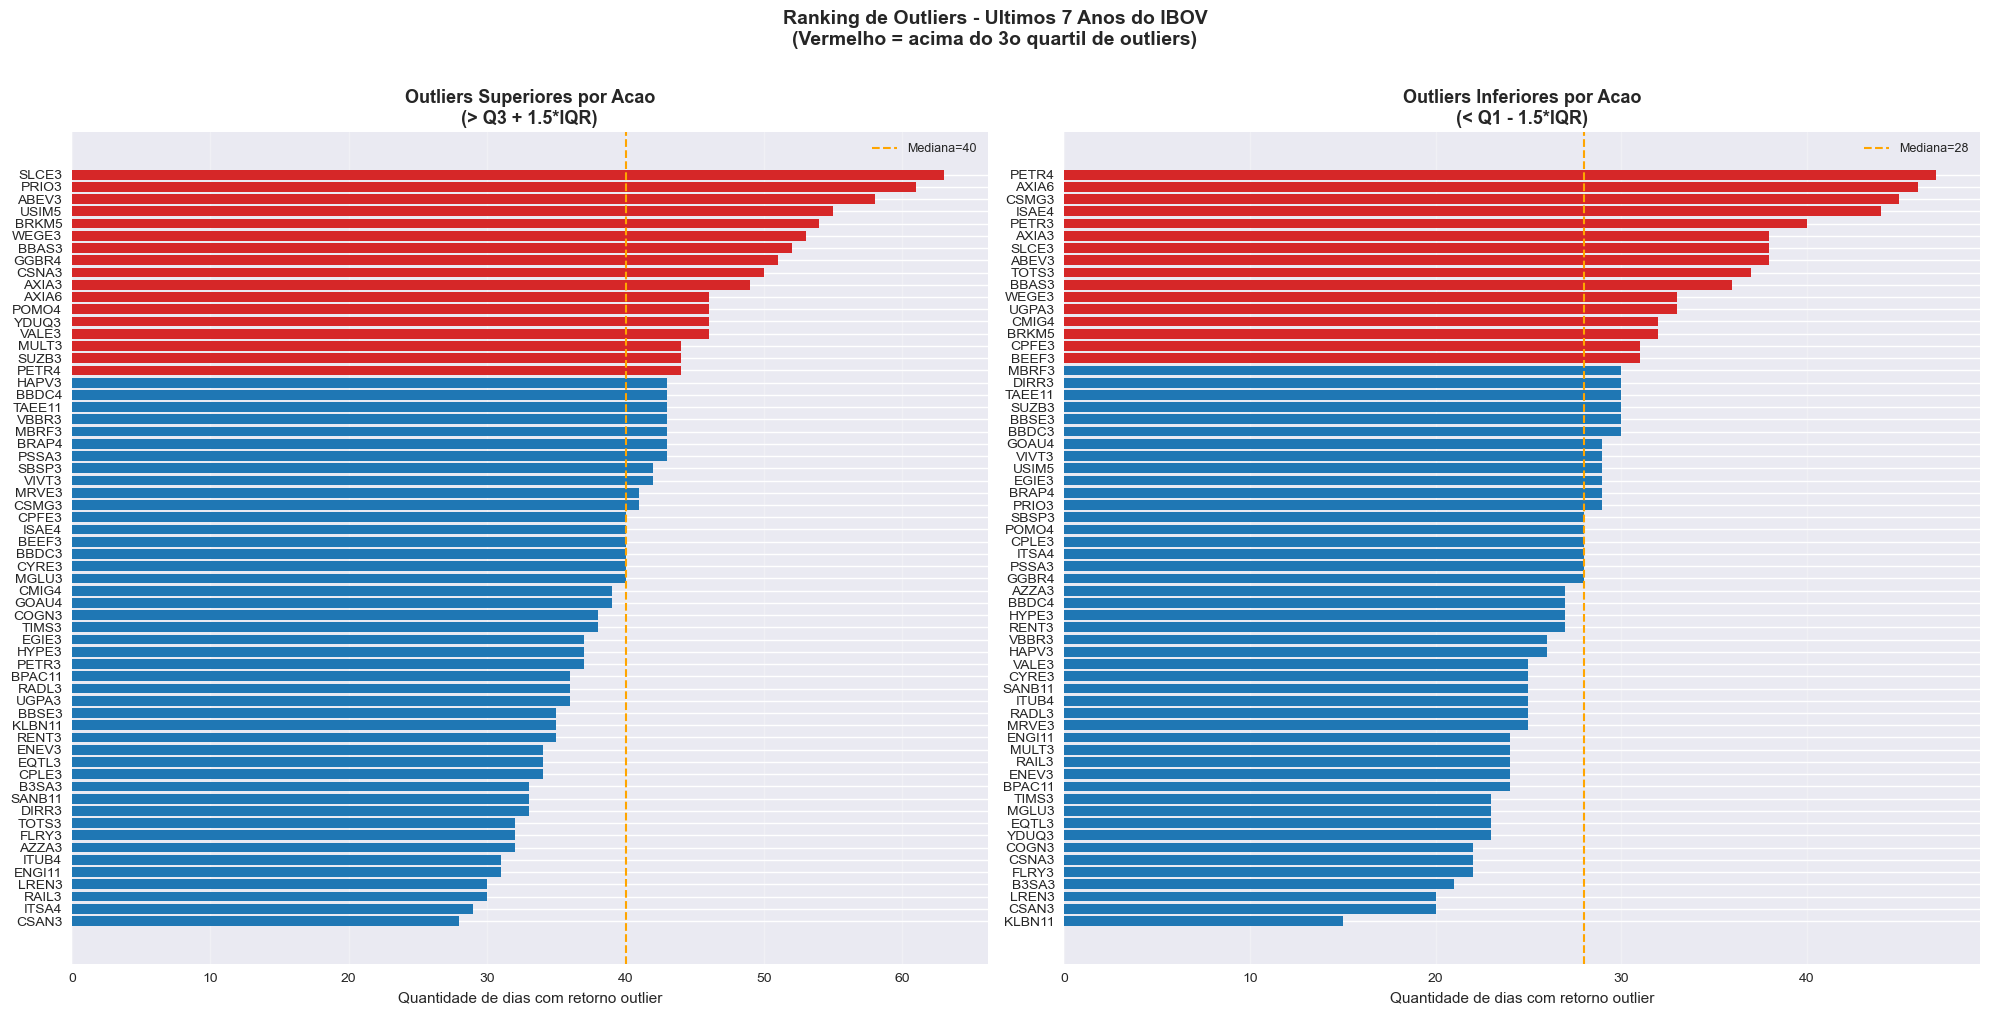

Grafico salvo como outliers_ranking_ibov.png


In [4]:
# GRAFICO DE BARRAS - RANKING DE OUTLIERS POR ACAO
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Painel esquerdo: outliers superiores
sup_sorted = resumo['Outliers_Sup'].sort_values(ascending=True)
colors_sup = ['#d62728' if v >= sup_sorted.quantile(0.75) else '#1f77b4'
                            for v in sup_sorted.values]
axes[0].barh([c.replace('.SA','') for c in sup_sorted.index],
                          sup_sorted.values, color=colors_sup)
axes[0].set_title('Outliers Superiores por Acao\n(> Q3 + 1.5*IQR)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Quantidade de dias com retorno outlier', fontsize=11)
axes[0].axvline(sup_sorted.median(), color='orange', linestyle='--',
                                linewidth=1.5, label=f'Mediana={sup_sorted.median():.0f}')
axes[0].legend(fontsize=9)
axes[0].grid(axis='x', alpha=0.3)

# Painel direito: outliers inferiores
inf_sorted = resumo['Outliers_Inf'].sort_values(ascending=True)
colors_inf = ['#d62728' if v >= inf_sorted.quantile(0.75) else '#1f77b4'
                            for v in inf_sorted.values]
axes[1].barh([c.replace('.SA','') for c in inf_sorted.index],
                          inf_sorted.values, color=colors_inf)
axes[1].set_title('Outliers Inferiores por Acao\n(< Q1 - 1.5*IQR)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Quantidade de dias com retorno outlier', fontsize=11)
axes[1].axvline(inf_sorted.median(), color='orange', linestyle='--',
                                linewidth=1.5, label=f'Mediana={inf_sorted.median():.0f}')
axes[1].legend(fontsize=9)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Ranking de Outliers - Ultimos 7 Anos do IBOV\n(Vermelho = acima do 3o quartil de outliers)',
                          fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outliers_ranking_ibov.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvo como outliers_ranking_ibov.png")

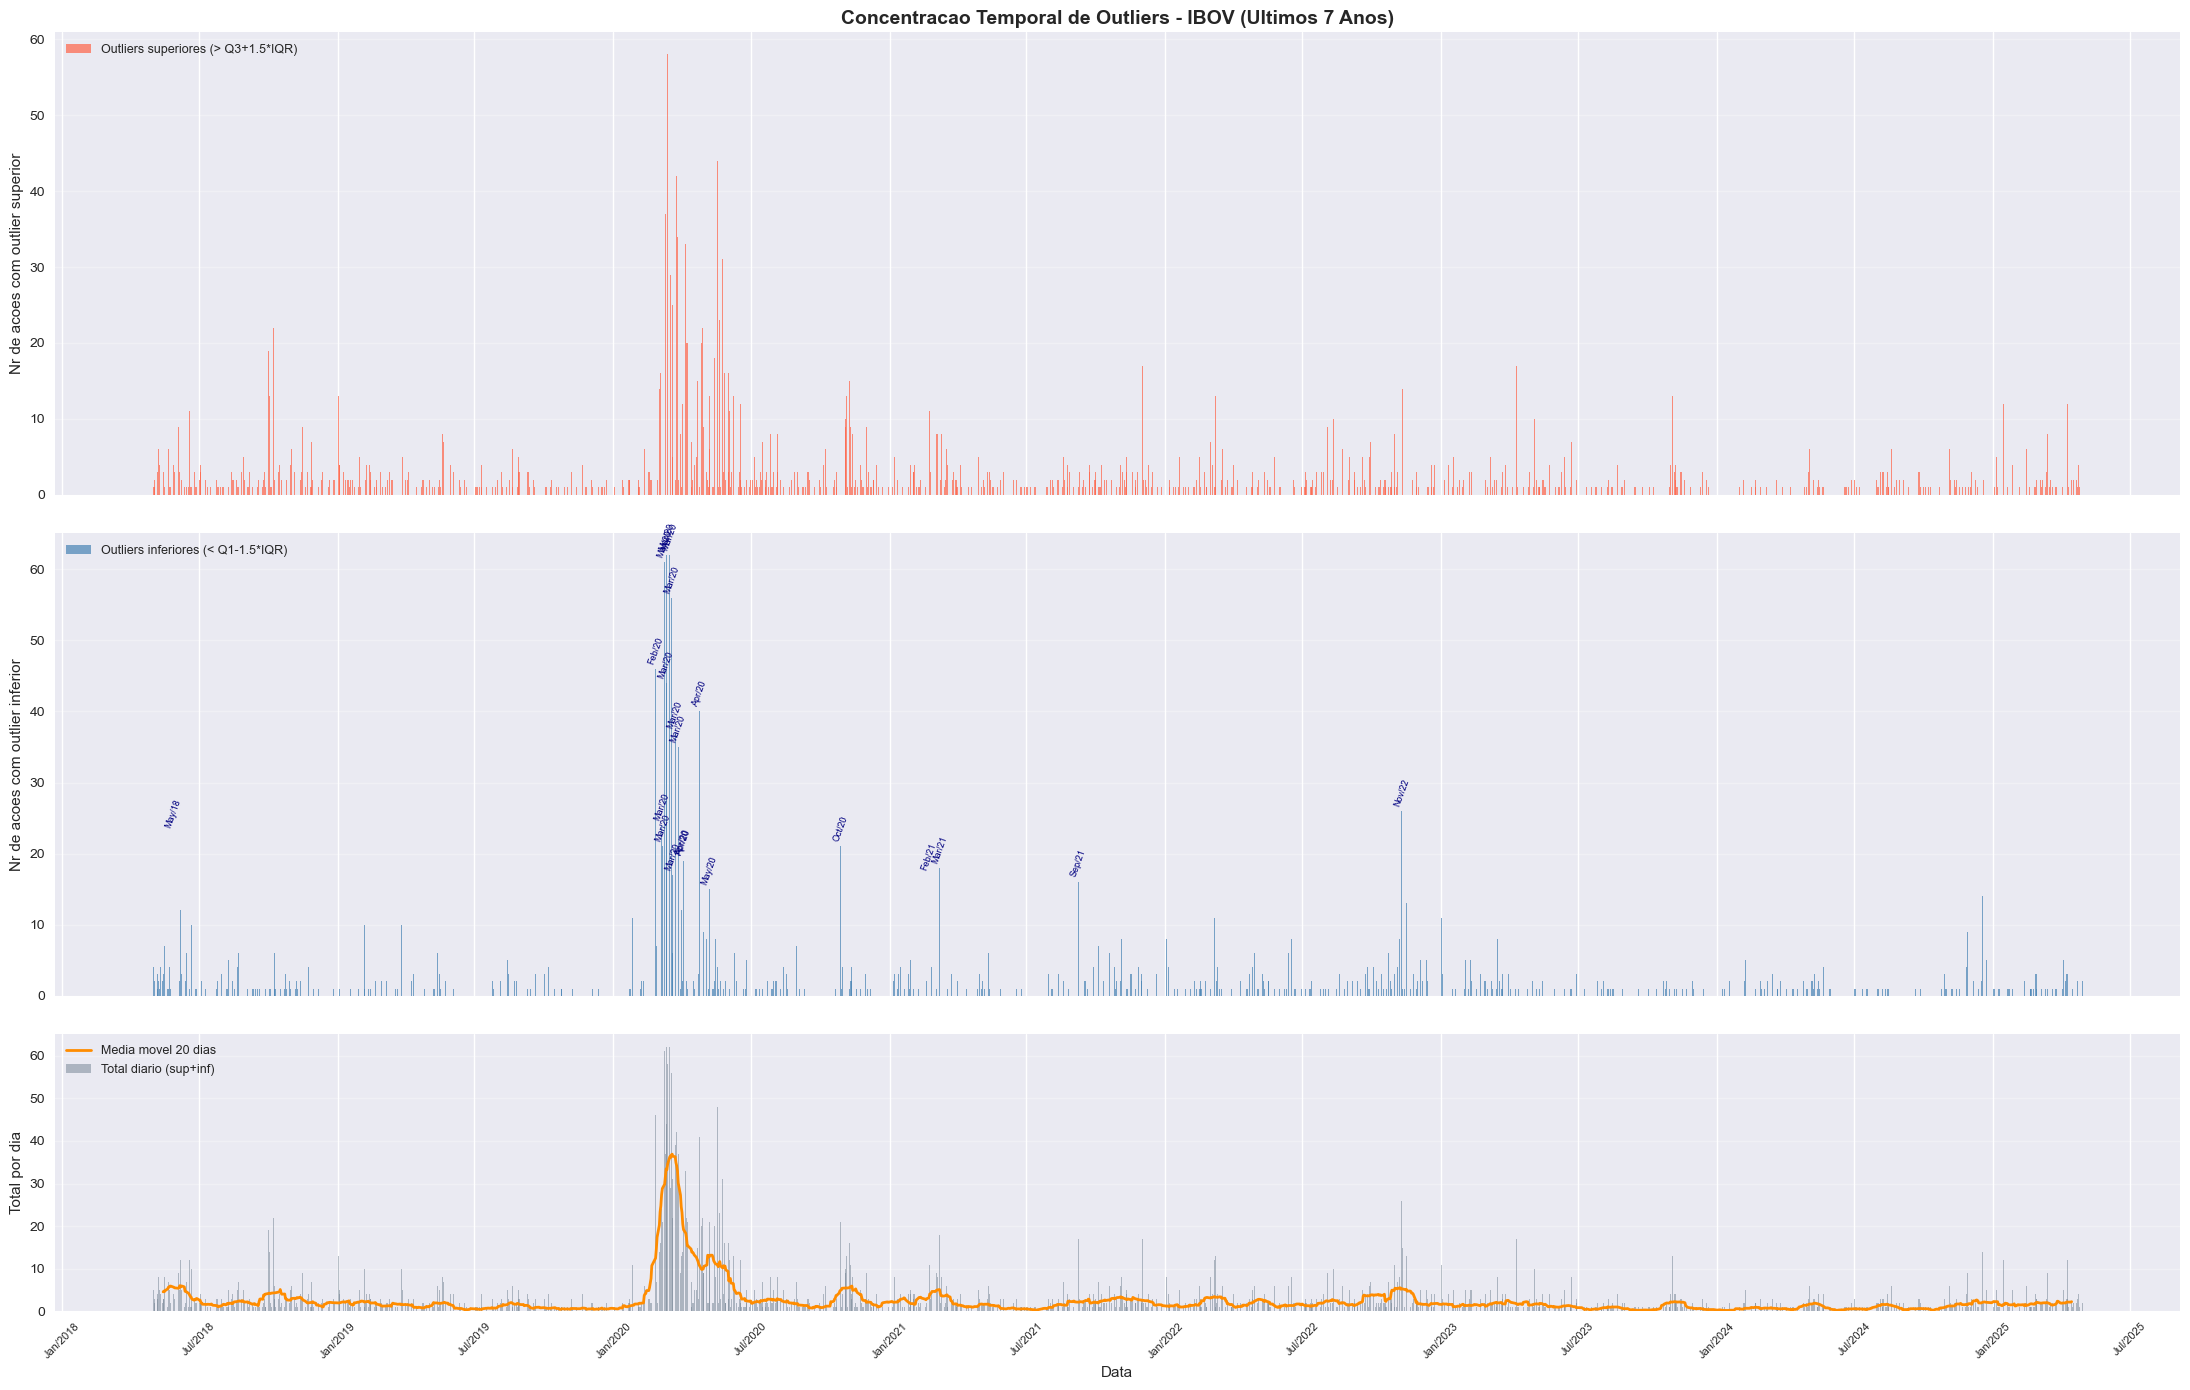

Grafico salvo como outliers_temporal_ibov.png


In [5]:
import matplotlib.dates as mdates

mask_sup = df_7anos.gt(limite_sup)
mask_inf = df_7anos.lt(limite_inf)

outliers_sup_dia = mask_sup.sum(axis=1)
outliers_inf_dia = mask_inf.sum(axis=1)
outliers_tot_dia = outliers_sup_dia + outliers_inf_dia

mm20 = outliers_tot_dia.rolling(20, center=True).mean()

fig, axes = plt.subplots(3, 1, figsize=(22, 14), sharex=True, gridspec_kw={'height_ratios': [2, 2, 1.2]})

axes[0].bar(outliers_sup_dia.index, outliers_sup_dia.values, color='tomato', alpha=0.7, width=1.2, label='Outliers superiores (> Q3+1.5*IQR)')
axes[0].set_ylabel('Nr de acoes com outlier superior', fontsize=11)
axes[0].set_title('Concentracao Temporal de Outliers - IBOV (Ultimos 7 Anos)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=9, loc='upper left')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, None)

axes[1].bar(outliers_inf_dia.index, outliers_inf_dia.values, color='steelblue', alpha=0.7, width=1.2, label='Outliers inferiores (< Q1-1.5*IQR)')
axes[1].set_ylabel('Nr de acoes com outlier inferior', fontsize=11)
axes[1].legend(fontsize=9, loc='upper left')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, None)

picos = outliers_inf_dia[outliers_inf_dia >= 15]
for dt, val in picos.items():
    axes[1].annotate(dt.strftime('%b/%y'), xy=(dt, val), xytext=(0, 4), textcoords='offset points', fontsize=6.5, ha='center', color='navy', rotation=70)

axes[2].bar(outliers_tot_dia.index, outliers_tot_dia.values, color='slategray', alpha=0.5, width=1.2, label='Total diario (sup+inf)')
axes[2].plot(mm20.index, mm20.values, color='darkorange', linewidth=2, label='Media movel 20 dias')
axes[2].set_ylabel('Total por dia', fontsize=11)
axes[2].set_xlabel('Data', fontsize=11)
axes[2].legend(fontsize=9, loc='upper left')
axes[2].grid(axis='y', alpha=0.3)
axes[2].set_ylim(0, None)

axes[2].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
axes[2].tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.savefig('outliers_temporal_ibov.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvo como outliers_temporal_ibov.png")